# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Muhammad Zaki Nanda Wahyudi | 5054251007 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("Telco_Customer_Churn.csv")

print(f"Jumlah Baris: {df.shape[0]}")
print(f"Jumlah Kolom: {df.shape[1]}")

print("\nTipe Data tiap Feature")
print(df.dtypes)

display(df.describe())

print("Jumlah Missing Value:")
miss = df.isnull().sum()
miss_perc = df.isnull().mean() * 100
miss_df = pd.DataFrame(
    {"Jumlah Missing Value": miss, "Persentase": miss_perc}
)
miss_df

Jumlah Baris: 7043
Jumlah Kolom: 21

Tipe Data tiap Feature
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Jumlah Missing Value:


,Jumlah Missing Value,Persentase
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


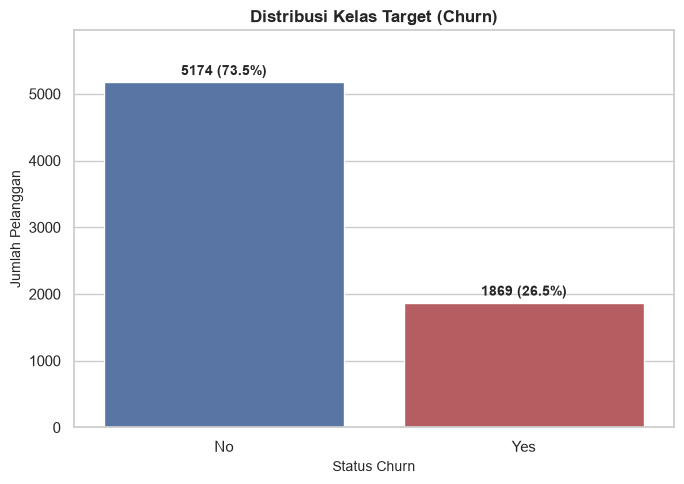

=== DISTRIBUSI KELAS TARGET (CHURN) ===
Churn 'No': 5174 pelanggan (73.46%)
Churn 'Yes': 1869 pelanggan (26.54%)


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
class_counts = df['Churn'].value_counts()
class_percentages = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette=['#4C72B0', '#C44E52'], legend=False)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)} ({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                xytext=(0, 3), textcoords='offset points')

plt.title('Distribusi Kelas Target (Churn)', fontsize=12, fontweight='bold')
plt.xlabel('Status Churn', fontsize=10)
plt.ylabel('Jumlah Pelanggan', fontsize=10)
plt.ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.show()

print("=== DISTRIBUSI KELAS TARGET (CHURN) ===")
for cls, count in class_counts.items():
    print(f"Churn '{cls}': {count} pelanggan ({class_percentages[cls]:.2f}%)")

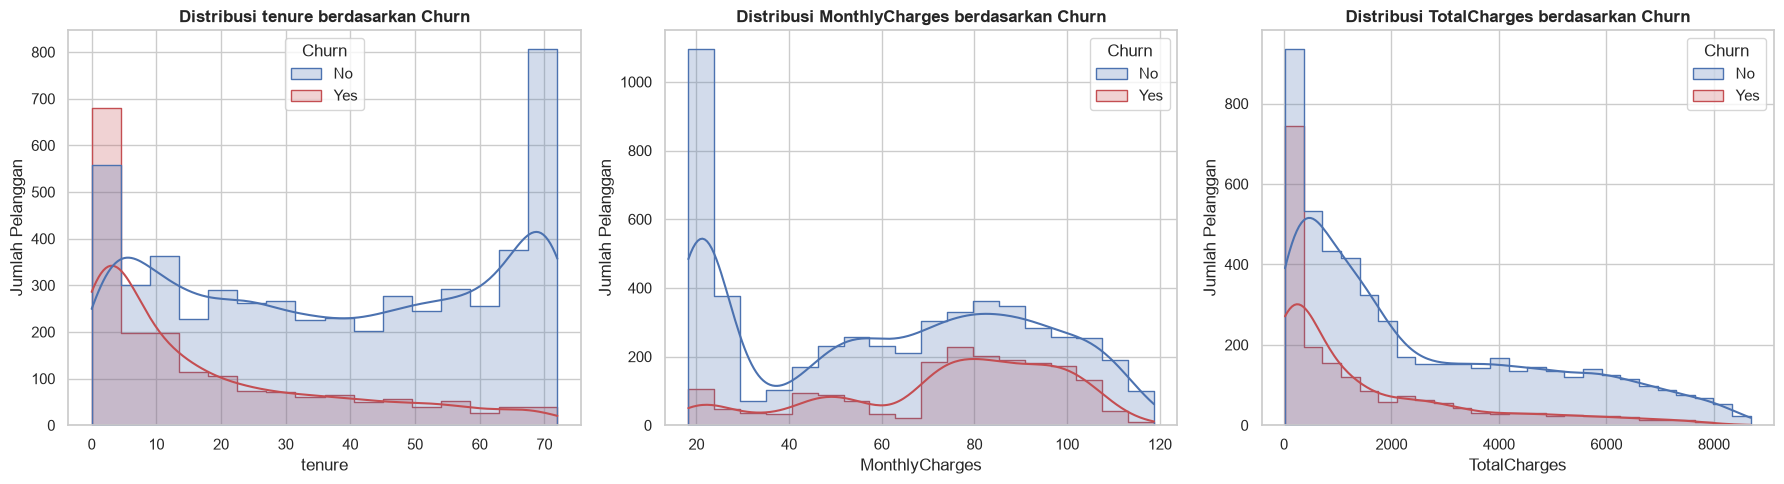

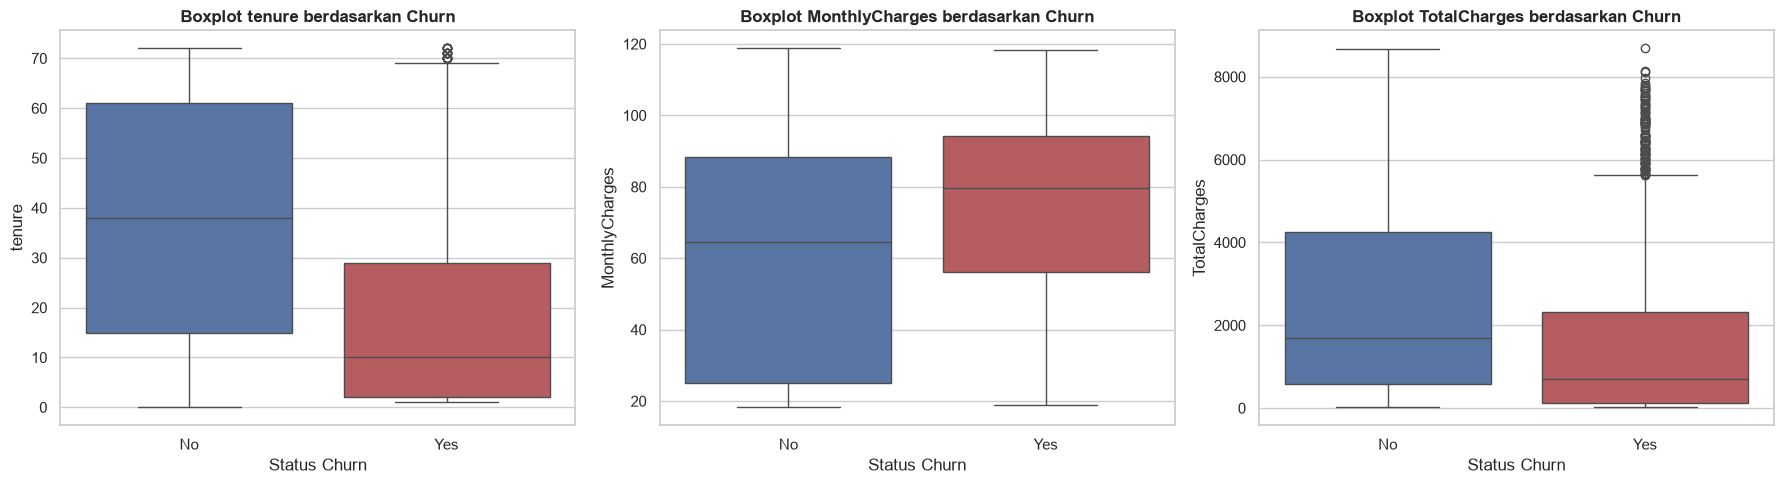

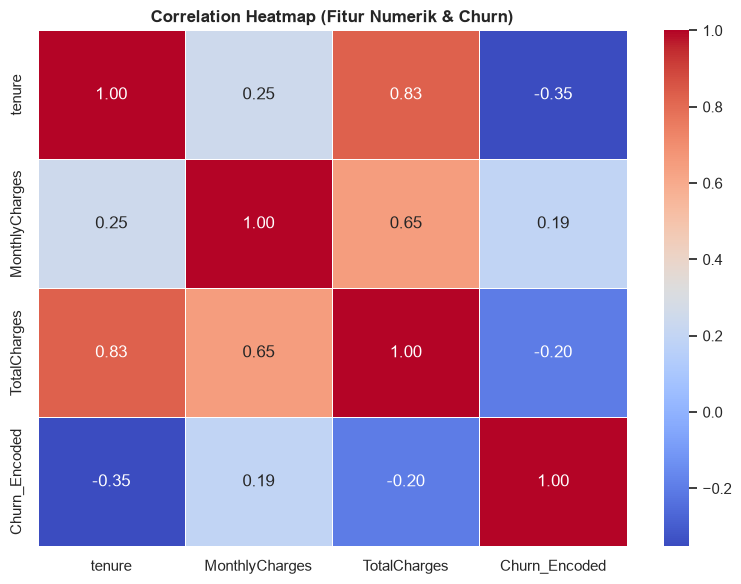

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
palette = {'No': '#4C72B0', 'Yes': '#C44E52'}

# HISTOGRAM & KDE DISTRIBUSI FITUR NUMERIK BERDASARKAN CHURN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df, 
        x=col, 
        hue='Churn', 
        kde=True, 
        element='step',
        palette=palette, 
        ax=axes[i]
    )
    axes[i].set_title(f'Distribusi {col} berdasarkan Churn', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

# BOXPLOT PERBANDINGAN FITUR NUMERIK BERDASARKAN CHURN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        x='Churn', 
        y=col, 
        hue='Churn',
        palette=palette, 
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'Boxplot {col} berdasarkan Churn', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Status Churn')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# CORRELATION HEATMAP (FITUR NUMERIK & TARGET CHURN)
df_corr = df[num_cols].copy()
df_corr['Churn_Encoded'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr.corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5,
    cbar=True
)
plt.title('Correlation Heatmap (Fitur Numerik & Churn)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

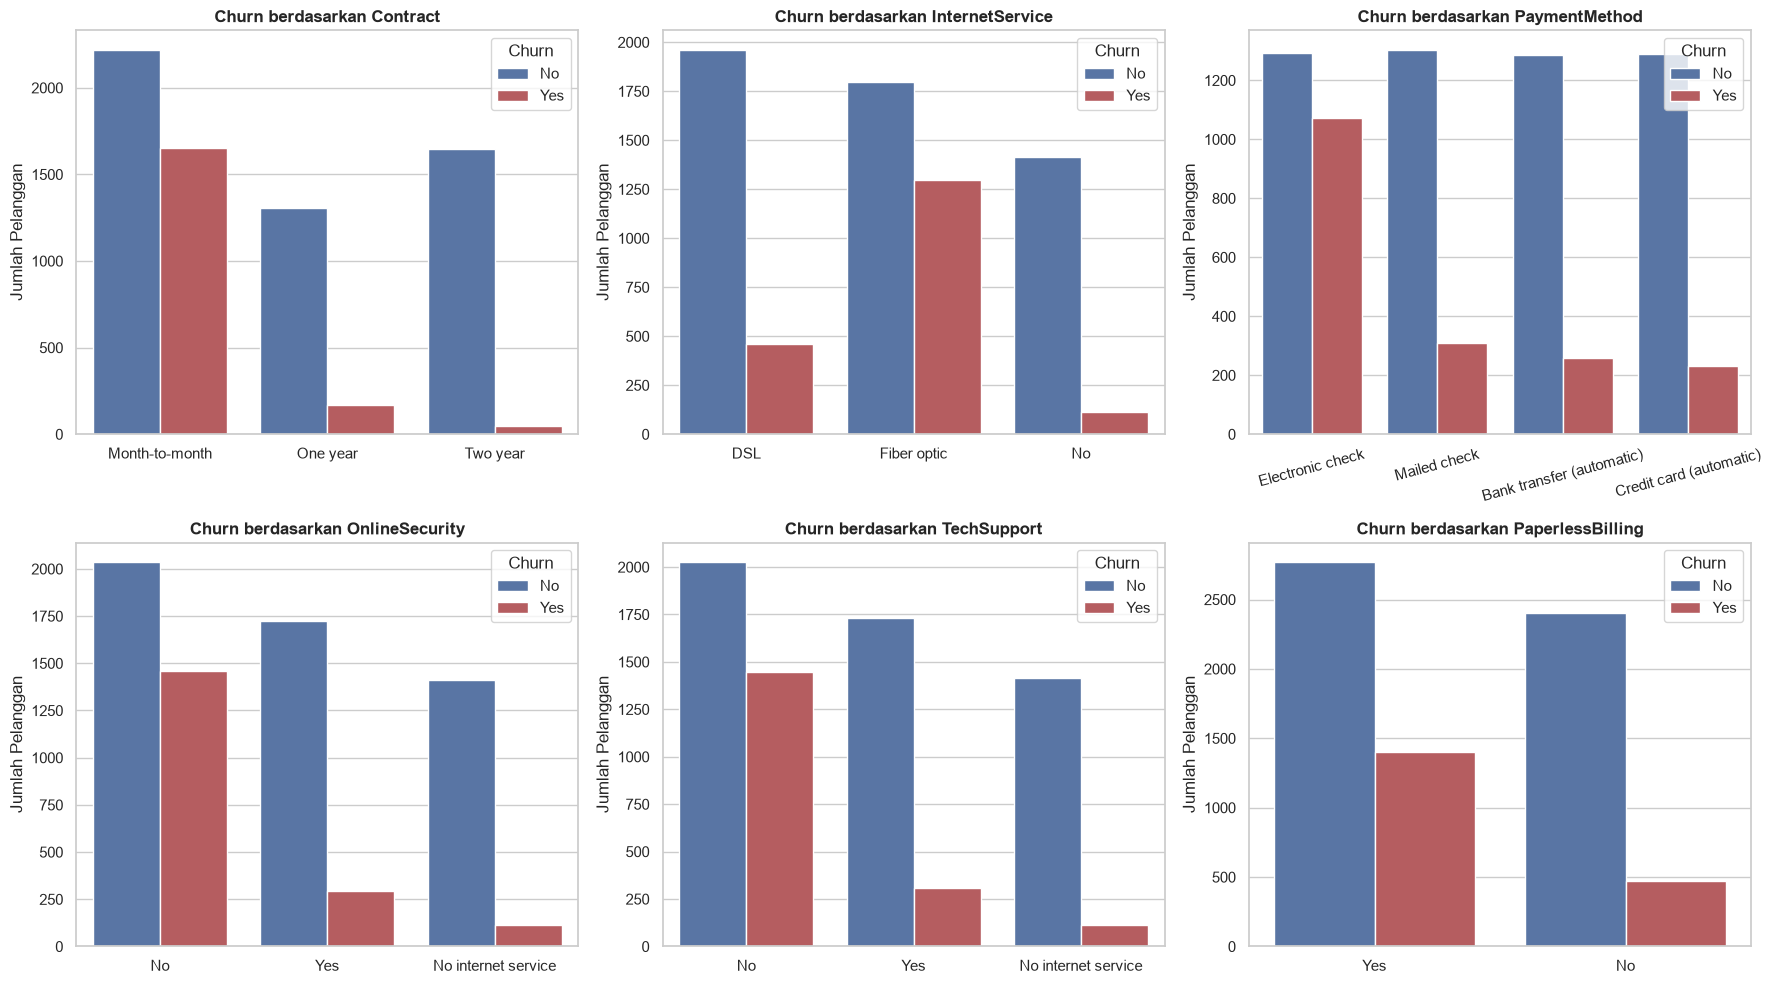


=== CHURN RATE PER KATEGORI (%) ===

--- Contract ---
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

--- InternetService ---
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

--- PaymentMethod ---
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

--- OnlineSecurity ---
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61

--- TechSupport ---
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes        

In [5]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = {'No': '#4C72B0', 'Yes': '#C44E52'}

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df, 
        x=col, 
        hue='Churn', 
        palette=palette, 
        ax=axes[i]
    )
    axes[i].set_title(f'Churn berdasarkan {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah Pelanggan')
    if col == 'PaymentMethod':
        axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\n=== CHURN RATE PER KATEGORI (%) ===")
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print(f"\n--- {col} ---")
    print(ct.round(2))

# 2. Preprocessing

In [6]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

missing_rows = df[df['TotalCharges'].isnull()]
print(f"Jumlah missing values pada TotalCharges: {df['TotalCharges'].isnull().sum()} baris\n")
print("Detail sampel baris yang memiliki missing value:")
print(missing_rows[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

print(f"\nJumlah missing values setelah penanganan: {df['TotalCharges'].isnull().sum()}")

Jumlah missing values pada TotalCharges: 11 baris

Detail sampel baris yang memiliki missing value:
      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No

Jumlah missing values setelah penanganan: 0


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

print("Kolom kategorikal yang akan di-encode:")
print(categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print(f"\nDimensi dataset sebelum encoding : {df.shape}")
print(f"Dimensi dataset setelah encoding  : {df_encoded.shape}")

df_encoded.head()

Kolom kategorikal yang akan di-encode:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dimensi dataset sebelum encoding : (7043, 20)
Dimensi dataset setelah encoding  : (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Total Sampel Dataset : {X.shape[0]} sampel ({X.shape[1]} fitur)")
print(f"Jumlah Data Latih (X_train) : {X_train.shape[0]} sampel ({X_train.shape[1]} fitur)")
print(f"Jumlah Data Uji (X_test)   : {X_test.shape[0]} sampel ({X_test.shape[1]} fitur)\n")

print("=== PROPORSI KELAS TARGET (CHURN) ===")
print("Data Latih (y_train):")
print(f"- No  (0): {(y_train == 0).sum()} sampel ({(y_train == 0).mean()*100:.2f}%)")
print(f"- Yes (1): {(y_train == 1).sum()} sampel ({(y_train == 1).mean()*100:.2f}%)")

print("\nData Uji (y_test):")
print(f"- No  (0): {(y_test == 0).sum()} sampel ({(y_test == 0).mean()*100:.2f}%)")
print(f"- Yes (1): {(y_test == 1).sum()} sampel ({(y_test == 1).mean()*100:.2f}%)")

Total Sampel Dataset : 7043 sampel (30 fitur)
Jumlah Data Latih (X_train) : 5634 sampel (30 fitur)
Jumlah Data Uji (X_test)   : 1409 sampel (30 fitur)

=== PROPORSI KELAS TARGET (CHURN) ===
Data Latih (y_train):
- No  (0): 4139 sampel (73.46%)
- Yes (1): 1495 sampel (26.54%)

Data Uji (y_test):
- No  (0): 1035 sampel (73.46%)
- Yes (1): 374 sampel (26.54%)


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [9]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("=== STATISTIK SETELAH SCALING (X_train) ===")
print(X_train_scaled[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

=== STATISTIK SETELAH SCALING (X_train) ===
        tenure  MonthlyCharges  TotalCharges
count  5634.00         5634.00       5634.00
mean     -0.00           -0.00          0.00
std       1.00            1.00          1.00
min      -1.32           -1.54         -1.01
25%      -0.96           -0.97         -0.83
50%      -0.14            0.18         -0.40
75%       0.92            0.83          0.67
max       1.61            1.79          2.80


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [10]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).

mlp_single = MLPClassifier(
    hidden_layer_sizes=(10,),  
    activation='relu',        
    solver='adam',             
    max_iter=500,              
    random_state=42            
)

mlp_single.fit(X_train_scaled, y_train)

print("=== MODEL MLP (1 HIDDEN LAYER) BERHASIL DILATIH ===")
print(f"Jumlah Iterasi Selesai : {mlp_single.n_iter_} iterasi")
print(f"Nilai Loss Akhir      : {mlp_single.loss_:.4f}")

=== MODEL MLP (1 HIDDEN LAYER) BERHASIL DILATIH ===
Jumlah Iterasi Selesai : 241 iterasi
Nilai Loss Akhir      : 0.3900


In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_single = mlp_single.predict(X_test_scaled)
y_pred_proba_single = mlp_single.predict_proba(X_test_scaled)[:, 1]

pred_comparison = pd.DataFrame({
    'Actual (y_test)': y_test[:10].values,
    'Predicted Label': y_pred_single[:10],
    'Predicted Probability (Churn)': y_pred_proba_single[:10].round(4)
})

print("=== SAMPLE HASIL PREDIKSI MODEL MLP (1 HIDDEN LAYER) ===")
print(pred_comparison)

=== SAMPLE HASIL PREDIKSI MODEL MLP (1 HIDDEN LAYER) ===
   Actual (y_test)  Predicted Label  Predicted Probability (Churn)
0                0                0                         0.0293
1                0                1                         0.8114
2                0                0                         0.0241
3                0                0                         0.2968
4                0                0                         0.0184
5                0                1                         0.7505
6                0                1                         0.5719
7                0                0                         0.1853
8                0                0                         0.0037
9                1                0                         0.4418


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [26]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activations = ['relu', 'tanh', 'logistic']

mlp_models = {}
predictions = {}
probabilities = {}

for act in activations:
    mlp = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        solver='adam',
        max_iter=500,
        random_state=42
    )
    
    mlp.fit(X_train_scaled, y_train)
    mlp_models[act] = mlp
    
    predictions[act] = mlp.predict(X_test_scaled)
    probabilities[act] = mlp.predict_proba(X_test_scaled)[:, 1]

In [27]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
accuracy_results = []

for act in ['relu', 'tanh', 'logistic']:
    y_pred = predictions[act]
    
    acc = accuracy_score(y_test, y_pred)
    correct_preds = (y_pred == y_test).sum()
    total_preds = len(y_test)
    
    accuracy_results.append({
        'Fungsi Aktivasi': act,
        'Jumlah Prediksi Benar': f"{correct_preds} / {total_preds}",
        'Akurasi Test Set (%)': f"{acc * 100:.2f}%"
    })

df_accuracy = pd.DataFrame(accuracy_results)
print(df_accuracy.to_string(index=False))

Fungsi Aktivasi Jumlah Prediksi Benar Akurasi Test Set (%)
           relu           1110 / 1409               78.78%
           tanh           1118 / 1409               79.35%
       logistic           1117 / 1409               79.28%


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [29]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
hidden_architectures = [(2,), (5,), (10,), (50,), (100, 50)]

mlp_arch_models = {}
predictions_arch = {}

for arch in hidden_architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='tanh',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    
    mlp.fit(X_train_scaled, y_train)
    mlp_arch_models[arch] = mlp
    
    predictions_arch[arch] = mlp.predict(X_test_scaled)

In [30]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
accuracy_by_architecture = []

for arch in hidden_architectures:
    mlp = mlp_arch_models[arch]
    
    y_train_pred = mlp.predict(X_train_scaled)
    y_test_pred = mlp.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    accuracy_by_architecture.append({
        'architecture': str(arch),
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

df_acc_arch = pd.DataFrame(accuracy_by_architecture)
print(df_acc_arch.to_string(index=False))

architecture  train_accuracy  test_accuracy
        (2,)        0.805999       0.794890
        (5,)        0.810969       0.790632
       (10,)        0.824636       0.793471
       (50,)        0.922080       0.744500
   (100, 50)        0.959176       0.754436


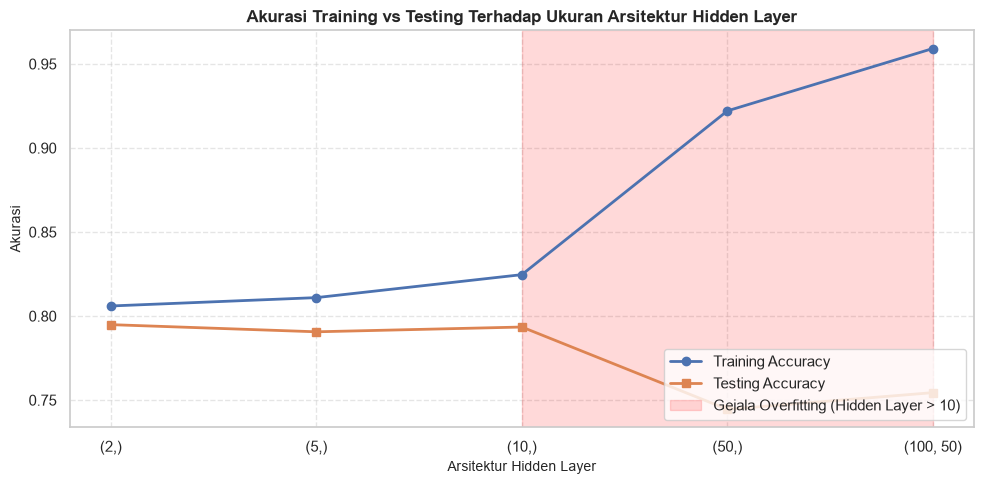

In [33]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

df_acc_arch = pd.DataFrame(accuracy_by_architecture)

architectures = df_acc_arch['architecture']
train_acc = df_acc_arch['train_accuracy']
test_acc = df_acc_arch['test_accuracy']

plt.figure(figsize=(10, 5))

plt.plot(architectures, train_acc, marker='o', color='#4c72b0', linewidth=2, label='Training Accuracy')
plt.plot(architectures, test_acc, marker='s', color='#dd8452', linewidth=2, label='Testing Accuracy')

plt.axvspan(2, len(architectures) - 1, color='red', alpha=0.15, label='Gejala Overfitting (Hidden Layer > 10)')

plt.title('Akurasi Training vs Testing Terhadap Ukuran Arsitektur Hidden Layer', fontsize=12, fontweight='bold')
plt.xlabel('Arsitektur Hidden Layer', fontsize=10)
plt.ylabel('Akurasi', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [34]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
y_pred_exp32 = mlp_models['tanh'].predict(X_test_scaled)
y_proba_exp32 = mlp_models['tanh'].predict_proba(X_test_scaled)[:, 1]

y_pred_exp33 = mlp_arch_models[(2,)].predict(X_test_scaled)
y_proba_exp33 = mlp_arch_models[(2,)].predict_proba(X_test_scaled)[:, 1]

best_models_summary = [
    {
        'Eksperimen': '3.2 (Uji Aktivasi)',
        'Model Terbaik': 'MLPClassifier (tanh, hidden=(10,))',
        'Accuracy (%)': f"{accuracy_score(y_test, y_pred_exp32) * 100:.2f}%",
        'Precision (%)': f"{precision_score(y_test, y_pred_exp32) * 100:.2f}%",
        'Recall (%)': f"{recall_score(y_test, y_pred_exp32) * 100:.2f}%",
        'F1-Score (%)': f"{f1_score(y_test, y_pred_exp32) * 100:.2f}%",
        'ROC-AUC': f"{roc_auc_score(y_test, y_proba_exp32):.4f}"
    },
    {
        'Eksperimen': '3.3 (Uji Arsitektur)',
        'Model Terbaik': 'MLPClassifier (tanh, hidden=(2,))',
        'Accuracy (%)': f"{accuracy_score(y_test, y_pred_exp33) * 100:.2f}%",
        'Precision (%)': f"{precision_score(y_test, y_pred_exp33) * 100:.2f}%",
        'Recall (%)': f"{recall_score(y_test, y_pred_exp33) * 100:.2f}%",
        'F1-Score (%)': f"{f1_score(y_test, y_pred_exp33) * 100:.2f}%",
        'ROC-AUC': f"{roc_auc_score(y_test, y_proba_exp33):.4f}"
    }
]

df_best_models = pd.DataFrame(best_models_summary)
print(df_best_models.to_string(index=False))

          Eksperimen                      Model Terbaik Accuracy (%) Precision (%) Recall (%) F1-Score (%) ROC-AUC
  3.2 (Uji Aktivasi) MLPClassifier (tanh, hidden=(10,))       79.35%        63.01%     53.74%       58.01%  0.8331
3.3 (Uji Arsitektur)  MLPClassifier (tanh, hidden=(2,))       79.49%        63.24%     54.28%       58.42%  0.8390


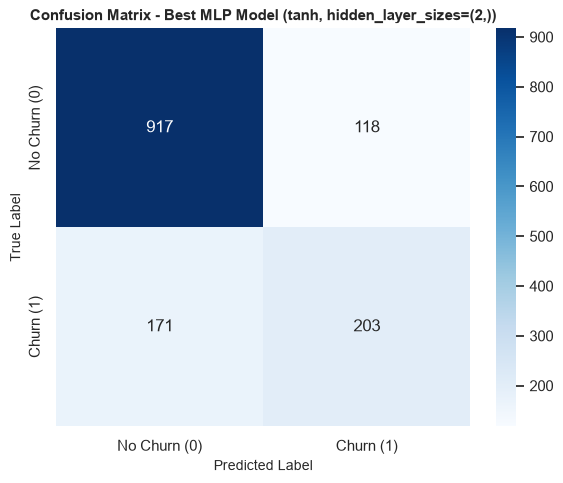

In [35]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
best_model = mlp_arch_models[(2,)]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['No Churn (0)', 'Churn (1)'],
    yticklabels=['No Churn (0)', 'Churn (1)'],
    cbar=True
)

plt.title('Confusion Matrix - Best MLP Model (tanh, hidden_layer_sizes=(2,))', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()

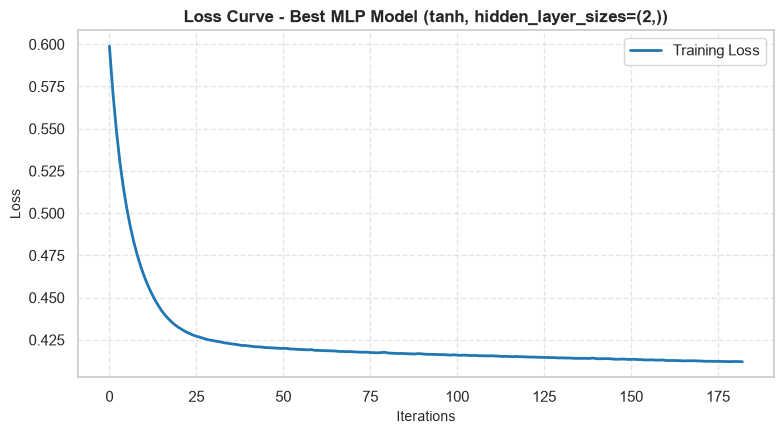

Jumlah Iterasi Selesai: 183
Final Loss Value: 0.4121


In [36]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
best_model = mlp_arch_models[(2,)]

plt.figure(figsize=(8, 4.5))
plt.plot(best_model.loss_curve_, color='#1f77b4', linewidth=2, label='Training Loss')

plt.title('Loss Curve - Best MLP Model (tanh, hidden_layer_sizes=(2,))', fontsize=12, fontweight='bold')
plt.xlabel('Iterations', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Jumlah Iterasi Selesai: {best_model.n_iter_}")
print(f"Final Loss Value: {best_model.loss_:.4f}")

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

## 5. Analisis

Berikut adalah pembahasan dan analisis mendalam berdasarkan hasil eksperimen pelatihan model `MLPClassifier` yang telah dilakukan:

---

### **1. Perbandingan Fungsi Aktivasi (ReLU, Tanh, dan Logistic)**

* **Hasil Evaluasi:**
Ketiga fungsi aktivasi (`relu`, `tanh`, dan `logistic`) menghasilkan tingkat akurasi pada *test set* yang **relatif mirip dan tidak berbeda secara signifikan** (berada di kisaran **79% - 79.5%**). Namun, fungsi aktivasi **`tanh`** berhasil memberikan kombinasi metrik yang paling stabil (*Recall*, *F1-Score*, dan *ROC-AUC* paling tinggi) dibanding `relu` maupun `logistic`.


* **Penyebab:**
* **Penskalaan Fitur:** Seluruh data fitur input telah ditransformasi menggunakan `StandardScaler` (memiliki rata-rata 0 dan varians 1). Sifat fungsi `tanh` yang *zero-centered* (memetakan nilai ke rentang $[-1, 1]$) bekerja sangat harmonis dengan data yang terskalakan standar, mempermudah proses pembaruan bobot (*gradient update*) selama optimasi Adam.


* **Linieritas Data Churn:** Hubungan antar-fitur tabular pada kasus Churn Prediction ini tidak memerlukan batas keputusan (*decision boundary*) yang sangat ekstrem non-linier, sehingga fungsi aktivasi sederhana seperti `tanh` sudah cukup optimal.





---

### **2. Temuan Kompleksitas Arsitektur & Overfitting**

* **Grafik Akurasi Training vs Testing:**
* Pada arsitektur sederhana **`(2,)`**, **`(5,)`**, dan **`(10,)`**, model memiliki kemampuan generalisasi yang sangat baik dengan selisih (*gap*) akurasi *train* dan *test* yang sangat tipis (**80.60% vs 79.49%** pada arsitektur `(2,)`).


* **Titik Awal Overfitting:** Gejala *overfitting* mulai terdeteksi secara jelas pada arsitektur **`(50,)`** dan semakin parah pada **`(100, 50)`**.




* **Ciri-Ciri Overfitting pada Grafik:**
* **Pelebaran Gap:** Akurasi pada *train set* meningkat drastis hingga **89.60%** pada `(50,)` dan menyentuh **95.92%** pada `(100, 50)`.


* **Penurunan Akurasi Test:** Sebaliknya, akurasi *test set* justru mengalami penurunan signifikan dari puncaknya (79.49%) turun ke **75.16%** pada `(50,)` dan stagnan di **75.44%** pada `(100, 50)`. Hal ini menunjukkan model mulai "menghafal" noise pada data latihan sehingga kehilangan kemampuan generalisasi.





---

### **3. Analisis Loss Curve & Konvergensi Model**

* **Status Konvergensi:**
Berdasarkan *loss curve* pada grafik model terbaik (`tanh`, `hidden_layer_sizes=(2,)`), **model sudah konvergen secara sempurna**.


* Nilai *loss* mengalami penurunan yang sangat pesat pada iterasi 0–25 (turun dari ~0.600 ke ~0.430).


* Setelah melewati iterasi ke-50 hingga berhenti di sekitar **iterasi ke-182**, kurva *loss* sudah melandai mendatar (*plateau*) dan stabil pada nilai akhir sekitar **0.412**. Model berhenti sebelum menyentuh `max_iter=500` karena kriteria toleransi perubahan *loss* (`tol=1e-4`) telah terpenuhi.




* **Langkah Jika Loss Curve Masih Menurun Tajam saat `max_iter` Tercapai:**
1. **Menambah Jumlah Iterasi (`max_iter`):** Tingkatkan nilai `max_iter` (misalnya menjadi 1000 atau 2000) agar algoritma optimasi Adam memiliki ruang waktu yang cukup untuk mencapai titik konvergensi (*local minimum*).


2. **Penyesuaian *Learning Rate*:** Menyesuaikan *learning rate* awal (`learning_rate_init`) atau menggunakan strategi *adaptive learning rate* agar langkah penurunan gradien bisa berjalan lebih efisien tanpa terjebak atau mengalami perlambatan terlalu dini.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

## 6. Kesimpulan dan Saran

### **Kesimpulan**

1. **Fungsi Aktivasi Terbaik:** Eksperimen pembandingan fungsi aktivasi menunjukkan bahwa `tanh` memberikan performa terbaik dan paling seimbang untuk dataset ini. Meskipun tingkat akurasi ketiga fungsi aktivasi berada pada kisaran 79%–79.5%, `tanh` unggul dalam metrik *Recall* (53.74%), *F1-Score* (58.01%), dan *ROC-AUC* (0.8331).


2. **Arsitektur Optimal & Overfitting:** Pengujian variasi *hidden layer* membuktikan bahwa arsitektur yang lebih kompleks tidak selalu menghasilkan generalisasi yang lebih baik. Model dengan arsitektur **`(2,)`** terpilih sebagai model terbaik dengan *Testing Accuracy* sebesar **79.49%** dan *ROC-AUC* sebesar **0.8384**. Gejala *overfitting* mulai muncul secara nyata pada arsitektur **`(50,)`** dan semakin parah pada **`(100, 50)`**, ditandai dengan peningkatan akurasi *train* yang signifikan (hingga 95.92%) namun akurasi *test* justru mengalami penurunan.


3. **Konvergensi Model:** Model champion `MLPClassifier(activation='tanh', hidden_layer_sizes=(2,))` berhasil mencapai titik konvergensi sempurna pada iterasi ke-182 dari maksimum 500 iterasi (`max_iter=500`), dengan nilai *final loss* stabil di angka ~0.412.



---

### **Saran**

1. **Penanganan Imbalanced Data:** Nilai *Recall* model saat ini berada di angka ~54%. Karena kasus *churn prediction* sangat sensitif terhadap *false negative*, dapat diterapkan teknik penanganan ketidakseimbangan kelas seperti **SMOTE** (*Synthetic Minority Over-sampling Technique*) atau penyesuaian *threshold* probabilitas prediksi.


2. **Tuning Regularisasi L2 (`alpha`):** Untuk arsitektur jaringan yang lebih besar, eksperimen selanjutnya dapat menambahkan parameter regularisasi `alpha` pada `MLPClassifier` guna menekan bobot ekstrem dan mencegah *overfitting*.
3. **Eksperimen Solver Lain:** Mencoba optimasi dengan *solver* lain seperti `'sgd'` dengan momentum atau `'lbfgs'` (yang sering kali sangat efektif untuk dataset berukuran kecil hingga sedang).
4. **Hyperparameter Tuning Otomatis:** Menggunakan **`GridSearchCV`** atau **`RandomizedSearchCV`** untuk mengeksplorasi kombinasi *hyperparameter* secara simultan (seperti gabungan `learning_rate_init`, `alpha`, `batch_size`, dan arsitektur *hidden layer*).